# Quantum Workflow Example

This notebook provides a tutorial of how to use the tools to generate quantum enhanced features outlined by [1]. The tools developed in the src directory and used in this notebook are easily extendible to different feature maps, circuit execution modes, and observables. As an example, this notebook generates quantum features with a standard unitary encoding circuit, and pauli correlation encoding to map observables to output features.

## References

[1] Rigetti Computing. (2023, April 25). *Recession prediction via signature kernels enhanced with quantum features*. Medium. https://medium.com/rigetti/recession-prediction-via-signature-kernels-enhanced-with-quantum-features-a608995d48f7

In [1]:
# imports from developed code
from src.quantum_utils.engineer_features import engineer_features
from src.quantum_utils.encoding_strategy.su_encoding_strategy import su_encoding_strategy
from src.quantum_utils.result_getters.pce_result_getter import pce_result_getter

In [2]:
# import Dataset
import pandas as pd

data_df = pd.read_parquet("data/processed/track_B_curated.parquet")
data_df.dropna(inplace=True)

## Core Workflow

The relationships that are captured with this method are affected by: 
- A) How classical input data is encoded into a quantum state
- B) How a quantum state is encoded in classical data

Although both stages are sometimes referred to as "encoding", however they serve fundamentally different purposes and are not generally interchangeable. Using identical mappings for both stages produces a trivial transformation with limited representational benefit.

The purpose of this framework is to provide a modular architecture where encoding strategies and result extraction methods can be independently developed, reused, and combined during experimentation.

---

## Workflow Overview

The feature engineering pipeline consists of four main steps:

### 1. Define the Qiskit Primitive and Number of Qubits

The Qiskit primitive (such as an estimator or sampler) and the number of qubits are initialized outside the framework classes. This simplifies experimentation within a runtime session and avoids repeatedly re-instantiating backend objects.

The number of qubits is defined first because it is required by both the encoding strategy and the result getter.

---

### 2. Define an Encoding Strategy

The encoding strategy specifies:

- The parameterized quantum circuit used to prepare the quantum state
- How classical input features are transformed into circuit parameter values

This component determines how information from the classical dataset is embedded into the Hilbert space representation.

---

### 3. Define a Result Getter

The result getter defines how the encoded quantum state is evaluated and translated back into classical information.

Depending on the implementation, this may involve:

- Simulation and/or hardware settings
- The set of Observables that will be measured
- post-processing on said observables to obtain expectation values

The output of this stage is a set of engineered classical features derived from the quantum representation.

---

### 4. Run `engineer_features`

The `engineer_features()` function combines:

- The encoding strategy
- The result getter
- The input dataset

and produces a transformed dataset containing quantum-enhanced features suitable for downstream machine learning tasks.

In [3]:
# imports from developed code
from src.quantum_utils.engineer_features import engineer_features
from src.quantum_utils.encoding_strategy.su_encoding_strategy import su_encoding_strategy
from src.quantum_utils.result_getters.pce_result_getter import pce_result_getter
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Estimator

sim = AerSimulator()
estimator = Estimator(mode=sim)

num_qubits = 3

# Define preprocessing and feature map settings.
encoding_strategy = su_encoding_strategy(n_qubits=num_qubits, 
                                         reps=1, 
                                         su2_gates=None, 
                                         entanglement='full')

# Define settings to execute circuit and extract features.
result_getter = pce_result_getter(num_qubits=num_qubits,
                                  num_features=9,
                                  num_operators=2,
                                  #estimator=estimator,
                                )

quantum_features, enhanced_circuit = engineer_features(data_df, 
                  encoding_strategy, 
                  result_getter,
                  return_circuit=True)

print("Dataframe of engineered quantum features:")
quantum_features.head()

Dataframe of engineered quantum features:


,XXI,XIX,IXX,YYI,YIY,IYY,ZZI,ZIZ,IZZ
0,0.097051,-0.057513,-0.592606,0.045276,-1.534562e-02,-0.589606,-0.466523,0.464162,-0.994939
1,0.137648,-0.122489,-0.889872,0.020851,6.938894e-18,-0.880788,-0.151480,0.149933,-0.989792
2,0.256679,-0.222291,-0.866025,0.010208,0.000000e+00,-0.836008,-0.039770,0.038391,-0.965339
3,0.288005,-0.210546,-0.731048,0.002171,-1.025920e-03,-0.698101,-0.007539,0.007199,-0.954932
4,0.354950,-0.307396,-0.866025,0.111823,0.000000e+00,-0.804797,-0.315040,0.292766,-0.929299


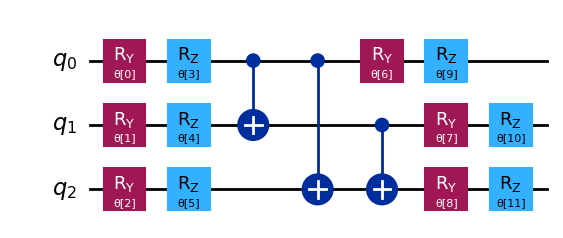

In [4]:
enhanced_circuit.draw('mpl')

The enhanced_df can then be used in any learning pipeline that would have been applied to data_df. In particular, using this method with a signature kernel + support vector machine pipeline has been shown to increate prediciton accuracy.

## Quantum Reservoir Example

In [5]:
from qiskit.circuit.library import efficient_su2
import numpy as np

from src.quantum_utils.quantum_reservoir import quantum_reservoir

series_indices = [[0,1,2], [3,4,5], [6,7,8]]

num_qubits = 6
num_encoding_qubits = 3
num_hidden_qubits = num_qubits - num_encoding_qubits

ansatz = efficient_su2(num_qubits, reps=1)
ansatz_params = 2*np.pi*np.random.rand(ansatz.num_parameters)
ansatz.assign_parameters(ansatz_params.tolist(), inplace=True)

sim = AerSimulator()
estimator = Estimator(mode=sim)

# Define preprocessing and feature map settings.
encoding_strategy = su_encoding_strategy(n_qubits=num_encoding_qubits, 
                                         reps=1, 
                                         su2_gates=None, 
                                         entanglement='full')

# Define settings to execute circuit and extract features.
result_getter = pce_result_getter(num_qubits=num_hidden_qubits,
                                  num_features=9,
                                  num_operators=2,
                                  #estimator=estimator,
                                )

quantum_reservoir_features, res_circuit = quantum_reservoir(data=data_df,
                                     series_indicies=series_indices, 
                                     ansatz=ansatz,
                                     encoding_strategy=encoding_strategy, 
                                     result_getter=result_getter,
                                     return_circuit=True)

print("Dataframe of engineered quantum features:")
quantum_reservoir_features.head()

Dataframe of engineered quantum features:


,XXI,XIX,IXX,YYI,YIY,IYY,ZZI,ZIZ,IZZ
0,-0.272659,-0.039084,0.144564,0.414193,-0.035114,-0.107913,0.207959,-0.306431,0.346913
1,0.479625,-0.216053,-0.176188,-0.346907,0.365019,-0.255689,0.326068,0.384600,0.340877
2,0.323350,0.165346,-0.186429,0.240724,-0.059750,-0.255601,-0.571950,0.306819,-0.482889


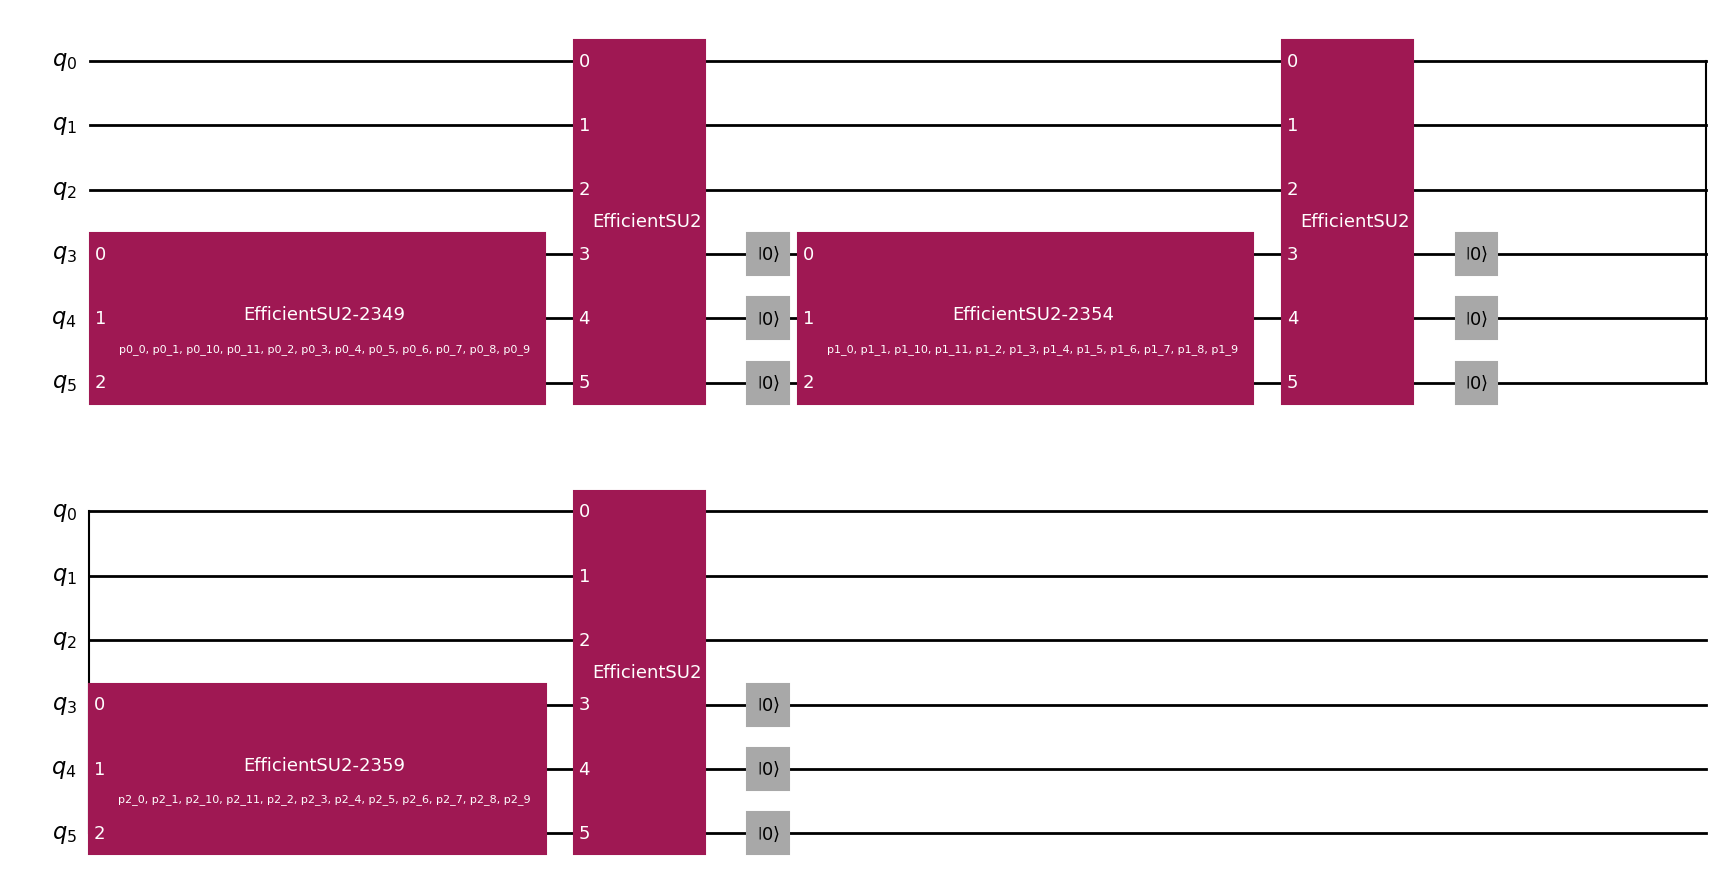

In [6]:
res_circuit.draw('mpl')

In [ ]:
import pandas as pd

# Get the row indices from data_df
target_rows = [idx_list[-1] + 1 for idx_list in series_indices]

# Select corresponding rows from data_df
selected_data = data_df.iloc[target_rows].reset_index(drop=True)

# Ensure quantum_reservoir_features is also aligned/reset
qr_features = quantum_reservoir_features.reset_index(drop=True)

# Concatenate horizontally
res_df = pd.concat([qr_features, selected_data], axis=1)

In [ ]:
res_df.head()

,XXI,XIX,IXX,YYI,YIY,IYY,ZZI,ZIZ,IZZ,UNRATE,PERMIT,S&P 500,UMCSENTx,T10Y3M_level,T10Y3M_delta
0,0.087611,0.152570,0.185086,-0.189946,0.386803,-0.422415,0.050029,-0.146137,0.467353,0.3,7.090077,0.026844,-3.8,1.16,0.07
1,0.209967,-0.509900,-0.379954,0.052411,-0.334152,-0.160226,-0.107544,0.067539,0.062264,0.3,7.119636,0.066628,3.4,1.09,-0.10
2,0.215419,-0.524937,-0.370149,0.060120,-0.340452,-0.146082,-0.134100,0.037177,0.095697,0.2,7.100027,0.013132,3.4,1.00,0.08
